# What makes a track a hit? Analysis of Spotify's top tracks of 2023

Analysis of the cleaned [Most Streamed Spotify Songs 2023](https://www.kaggle.com/datasets/nelgiriyewithana/top-spotify-songs-2023) dataset.
Data cleaning and preparation are in `data/raw.ipynb`; here we work with the ready `spotify-2023-clean.csv`.

**Plan:**
1. Import libraries
2. Load the cleaned data
3. Hypothesis 1: major-key tracks are streamed more than minor-key ones (t-test)
4. Hypothesis 2: playlists are linked to streams more strongly than any audio feature (correlation)
5. Hypothesis 3: releases have seasonality
6. Hypothesis 4: more co-authors -> higher chance of charting
7. Advanced part: trend and seasonality of the release time series (decomposition)
8. Conclusions

## 1. Import libraries

In [1]:
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")  # keep library technical warnings out of the output
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 2. Load the cleaned data

In [2]:
df = pd.read_csv("../data/spotify-2023-clean.csv", parse_dates=["release_date"])
print("shape:", df.shape)
df.head()

shape: (948, 29)


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,release_date,track_age_years,total_playlists,chart_platforms,genre
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,83,31,0,8,4,2023-07-14,0,641,4,K-Pop
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,74,7,0,10,4,2023-03-23,0,1580,4,Afro-Pop
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,53,17,0,31,6,2023-06-30,0,1582,4,Pop
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,72,11,0,11,15,2019-08-23,4,8099,4,Pop
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,80,14,63,11,6,2023-05-18,0,3304,4,Latin


In [3]:
audio_features = [
    "bpm", "danceability_%", "valence_%", "energy_%",
    "acousticness_%", "instrumentalness_%", "liveness_%", "speechiness_%",
]

df[["streams", "total_playlists", "chart_platforms", "artist_count"] + audio_features].describe().round(1)

,streams,total_playlists,chart_platforms,artist_count,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,948.000,948.000,948.000,948.000,948.000,948.000,948.000,948.000,948.000,948.000,948.000,948.000
mean,"514,017,927.500","5,659.900",2.500,1.600,122.500,67.000,51.400,64.300,27.200,1.600,18.200,10.200
std,"567,927,731.800","8,934.600",1.300,0.900,28.000,14.600,23.500,16.600,26.000,8.400,13.700,9.900
min,"2,762.000",34.000,0.000,1.000,65.000,23.000,4.000,9.000,0.000,0.000,3.000,2.000
25%,"141,143,862.000",914.500,1.000,1.000,99.000,57.000,32.000,53.000,6.000,0.000,10.000,4.000
50%,"287,690,252.000","2,306.000",3.000,1.000,120.500,69.000,51.000,66.000,18.000,0.000,12.000,6.000
75%,"672,942,469.000","5,791.800",4.000,2.000,140.000,78.000,70.000,77.000,43.000,0.000,23.200,11.000
max,"3,703,895,074.000","62,623.000",4.000,8.000,206.000,96.000,97.000,97.000,97.000,91.000,97.000,64.000


## 3. Hypothesis 1: major-key tracks get more streams than minor-key ones

We compare the `streams` distribution of major- and minor-key tracks. Because streams are heavily
right-skewed, alongside Welch's t-test (comparison of means) we also run the non-parametric
Mann-Whitney test (comparison of distributions), so the conclusion does not rest on outliers alone.

In [4]:
major = df.loc[df["mode"] == "Major", "streams"]
minor = df.loc[df["mode"] == "Minor", "streams"]

print(f"Major: n={len(major)}, mean={major.mean():,.0f}, median={major.median():,.0f}")
print(f"Minor: n={len(minor)}, mean={minor.mean():,.0f}, median={minor.median():,.0f}")
print()

t_stat, t_p = stats.ttest_ind(major, minor, equal_var=False)
u_stat, u_p = stats.mannwhitneyu(major, minor, alternative="two-sided")
print(f"Welch t-test:   t={t_stat:.3f}, p-value={t_p:.3f}")
print(f"Mann-Whitney:   U={u_stat:,.0f}, p-value={u_p:.3f}")

Major: n=546, mean=535,123,196, median=301,494,871
Minor: n=402, mean=485,352,564, median=272,691,474

Welch t-test:   t=1.344, p-value=0.179
Mann-Whitney:   U=116,532, p-value=0.103


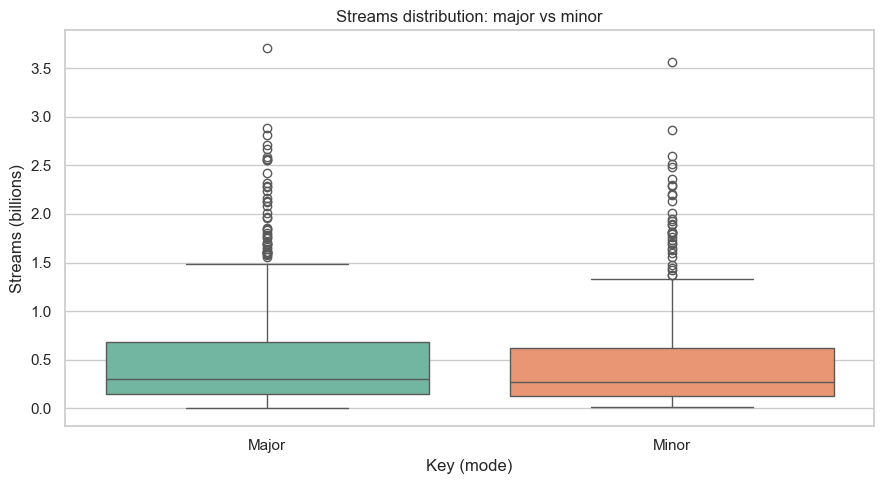

In [5]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="mode", y="streams", hue="mode", palette="Set2", legend=False, ax=ax)
ax.set_title("Streams distribution: major vs minor")
ax.set_xlabel("Key (mode)")
ax.set_ylabel("Streams (billions)")
ax.yaxis.set_major_formatter(lambda x, _: f"{x / 1e9:.1f}")
plt.tight_layout()
plt.show()

**Conclusion for H1.** Welch's t-test gives p=0.179, Mann-Whitney p=0.103 - both above the 0.05 threshold, so the difference in streams between major and minor keys is not statistically significant. The hypothesis is not supported: the key by itself does not make a track more popular.

## 4. Hypothesis 2: the number of playlists is linked to streams more strongly than any audio feature

We compute the correlation of `streams` with `total_playlists` and with each audio feature.
We use Spearman (rank) correlation: it is robust to the skew of streams and captures a
monotonic, not necessarily linear, relationship.

In [6]:
predictors = ["total_playlists"] + audio_features
corr = (
    df[predictors + ["streams"]]
    .corr(method="spearman")["streams"]
    .drop("streams")
    .sort_values(key=abs, ascending=False)
)
corr.to_frame("corr_with_streams").round(3)

,corr_with_streams
total_playlists,0.834
speechiness_%,-0.108
danceability_%,-0.082
liveness_%,-0.063
acousticness_%,-0.059
valence_%,-0.039
energy_%,-0.033
instrumentalness_%,-0.004
bpm,0.003


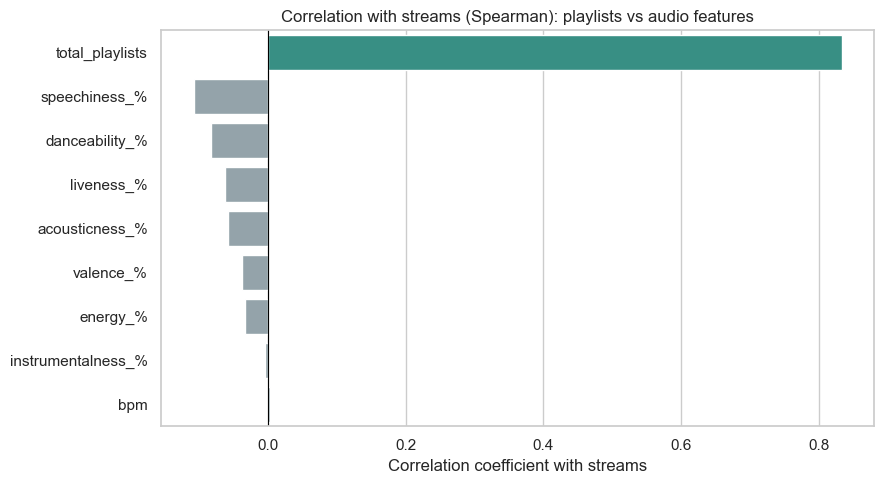

In [7]:
fig, ax = plt.subplots()
colors = ["#2a9d8f" if i == "total_playlists" else "#90a4ae" for i in corr.index]
sns.barplot(x=corr.values, y=corr.index, hue=corr.index, palette=colors, legend=False, ax=ax)
ax.set_title("Correlation with streams (Spearman): playlists vs audio features")
ax.set_xlabel("Correlation coefficient with streams")
ax.set_ylabel("")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

**Conclusion for H2.** `total_playlists` has a markedly higher correlation with streams (~0.83) than
any audio feature (for most audio features it is near zero). The hypothesis is supported: getting into
playlists is linked to the number of streams far more strongly than how the track sounds.

Correlation here does not imply causation: `total_playlists` and `streams` are partly
endogenous - both reflect the track's level of distribution and popularity, so a high correlation
between them is expected.

## 5. Hypothesis 3: releases have seasonality

We look at the release month from two angles: how many tracks are released each month (label
activity) and what median number of streams those tracks gather. To prevent track age from skewing
the picture (old hits accumulated streams over years), for streams we take only 2022-2023 releases.
We test the difference in medians across months with the Kruskal-Wallis test.

In [8]:
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

recent = df[df["released_year"] >= 2022]
by_month = recent.groupby("released_month").agg(
    releases=("streams", "size"),
    median_streams=("streams", "median"),
).reindex(range(1, 13))
by_month.index = month_names

groups = [g["streams"].values for _, g in recent.groupby("released_month")]
kw_stat, kw_p = stats.kruskal(*groups)
print(f"Kruskal-Wallis across months (streams, 2022-2023 releases): H={kw_stat:.2f}, p-value={kw_p:.3f}")
by_month.round(0)

Kruskal-Wallis across months (streams, 2022-2023 releases): H=37.20, p-value=0.000


,releases,median_streams
Jan,56,"153,152,312.000"
Feb,51,"201,660,859.000"
Mar,63,"162,887,075.000"
Apr,50,"168,494,568.000"
May,104,"186,255,366.000"
Jun,61,"115,331,792.000"
Jul,40,"163,792,134.000"
Aug,19,"284,785,823.000"
Sep,20,"199,415,584.000"
Oct,36,"275,489,905.000"


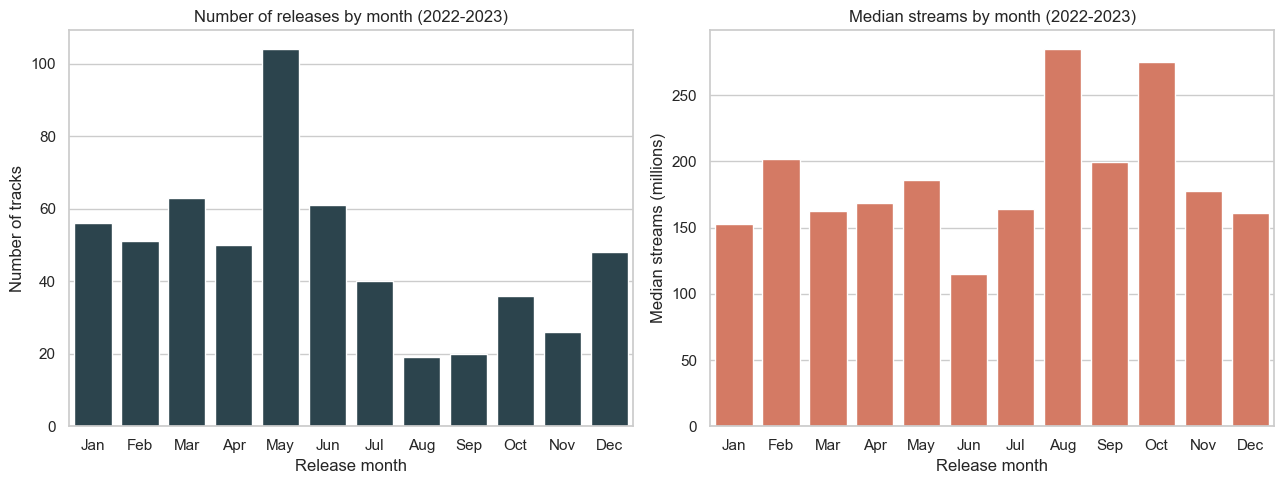

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=by_month.index, y=by_month["releases"], color="#264653", ax=ax1)
ax1.set_title("Number of releases by month (2022-2023)")
ax1.set_xlabel("Release month")
ax1.set_ylabel("Number of tracks")

sns.barplot(x=by_month.index, y=by_month["median_streams"], color="#e76f51", ax=ax2)
ax2.set_title("Median streams by month (2022-2023)")
ax2.set_xlabel("Release month")
ax2.set_ylabel("Median streams (millions)")
ax2.yaxis.set_major_formatter(lambda x, _: f"{x / 1e6:.0f}")

plt.tight_layout()
plt.show()

**Conclusion for H3.** Seasonality is clearly visible in the *number* of releases: the peak is in May,
with noticeable spikes early in the year and in March. For *streams*, the Kruskal-Wallis test shows
significant differences between months (p < 0.001), but they do not support the hypothesis: the months
with the most releases (May, March, January) yield only average median streams, while the highest
medians belong to the sparsely populated August and October (n = 19 and 36), i.e. the differences rest
on a few observations. The hypothesis in its original form ("releases at the start of the year and
before summer gather more") is not supported: the release timing is linked to *how many* tracks are
released, but does not guarantee them more streams.

## 6. Hypothesis 4: more co-authors -> higher chance of charting

As a measure of "charting" we use `chart_platforms` - on how many of the four platforms
(Spotify, Apple, Deezer, Shazam) the track entered the chart. We compute the rank correlation with
`artist_count` and compare solo tracks with collaborations (Mann-Whitney).

In [10]:
rho, rho_p = stats.spearmanr(df["artist_count"], df["chart_platforms"])
print(f"Spearman correlation artist_count vs chart_platforms: rho={rho:.3f}, p-value={rho_p:.3f}")

solo = df.loc[df["artist_count"] == 1, "chart_platforms"]
collab = df.loc[df["artist_count"] > 1, "chart_platforms"]
u_stat, u_p = stats.mannwhitneyu(solo, collab, alternative="two-sided")
print(f"\nSolo (n={len(solo)}): mean chart_platforms={solo.mean():.2f}")
print(f"Collabs (n={len(collab)}): mean chart_platforms={collab.mean():.2f}")
print(f"Mann-Whitney solo vs collab: U={u_stat:,.0f}, p-value={u_p:.3f}")

Spearman correlation artist_count vs chart_platforms: rho=0.024, p-value=0.457

Solo (n=582): mean chart_platforms=2.43
Collabs (n=366): mean chart_platforms=2.55
Mann-Whitney solo vs collab: U=99,970, p-value=0.101


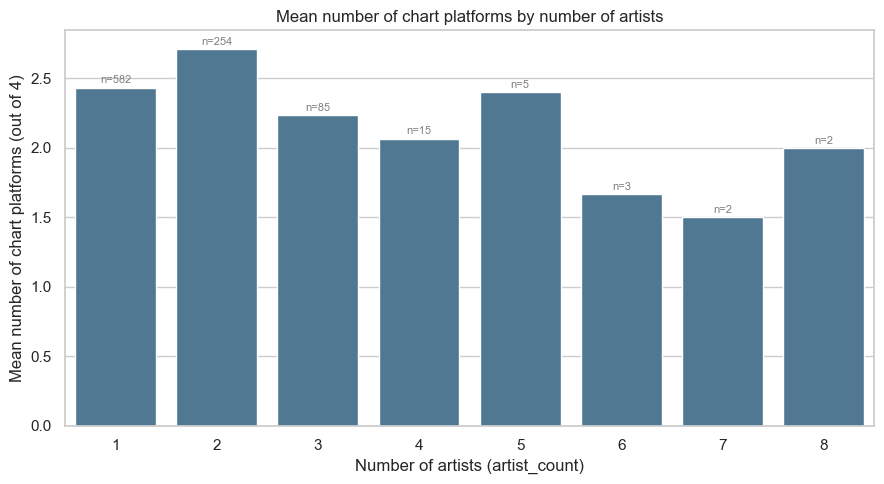

In [11]:
by_artists = df.groupby("artist_count")["chart_platforms"].agg(["mean", "size"])

fig, ax = plt.subplots()
sns.barplot(x=by_artists.index, y=by_artists["mean"], color="#457b9d", ax=ax)
ax.set_title("Mean number of chart platforms by number of artists")
ax.set_xlabel("Number of artists (artist_count)")
ax.set_ylabel("Mean number of chart platforms (out of 4)")
for i, (m, n) in enumerate(zip(by_artists["mean"], by_artists["size"])):
    ax.text(i, m + 0.03, f"n={n}", ha="center", fontsize=8, color="gray")
plt.tight_layout()
plt.show()

**Conclusion for H4.** The correlation between the number of co-authors and charting is near zero
(rho=0.024, p=0.457). The hypothesis "more co-authors = higher chance of charting" is not supported:
the link, if any, is very weak, and the groups with large artist_count are small (see n on the bars).

## 7. Advanced part: trend and seasonality of the release time series

Hypothesis 3 hinted at seasonality by comparing months, but that is a cross-sectional view. Here we build a proper **time series** - the number of releases per month - and decompose it into **trend + seasonality + residual** with an additive decomposition (`statsmodels.seasonal_decompose`, period 12 months).

We take the continuous span **2021-01 to 2023-07**: over it the dataset has enough tracks in each month, whereas earlier years are represented by a few "surviving" hits and the series there is patchy. It is important to keep the sampling bias in mind: this is a slice of *top-2023*, so the rising trend in the number of releases reflects not only real label activity but also the fact that recent tracks are more likely to make the top (survivorship bias). So we interpret the trend cautiously, and the main interest is in the **seasonal** component: which months consistently stand out.

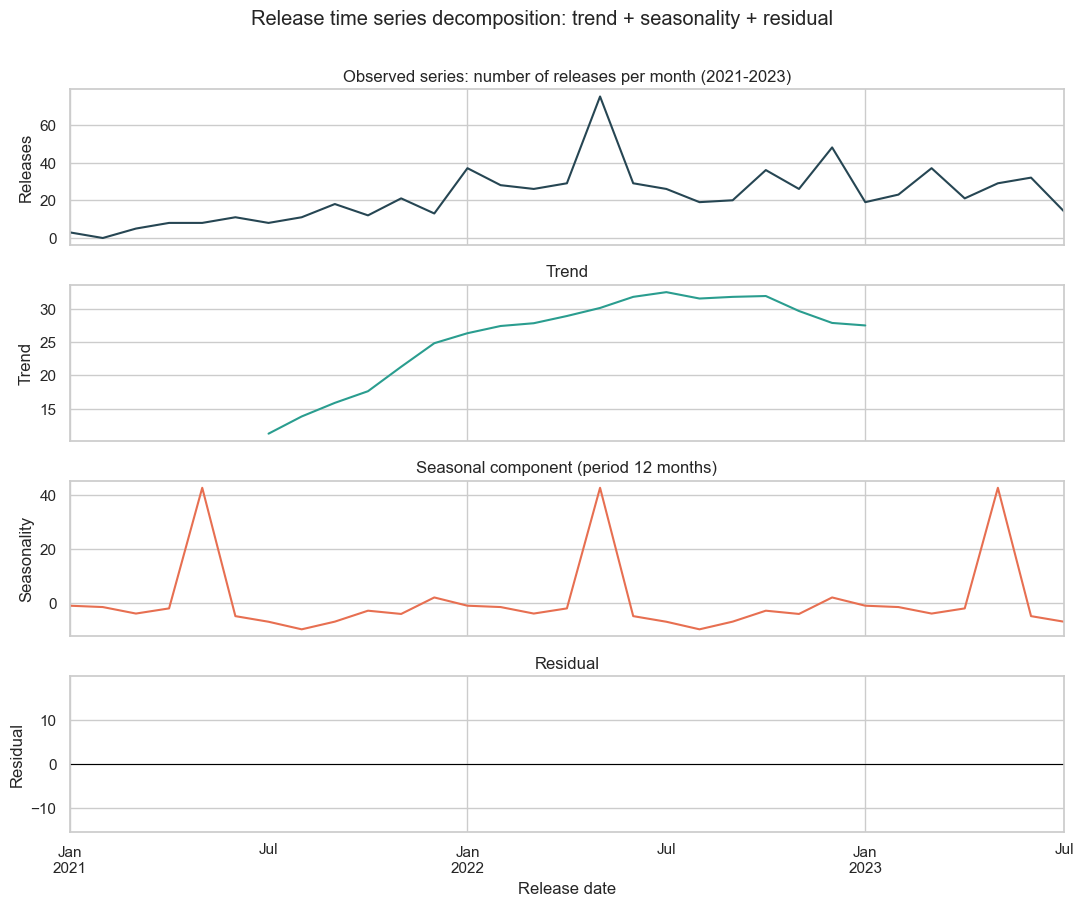

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

# continuous monthly series of the number of releases over the span with dense data
ts = (
    df.set_index("release_date")
    .resample("MS")
    .size()
    .loc["2021-01":"2023-07"]
    .asfreq("MS")
)
ts.name = "releases"

decomp = seasonal_decompose(ts, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
decomp.observed.plot(ax=axes[0], color="#264653")
axes[0].set_ylabel("Releases")
axes[0].set_title("Observed series: number of releases per month (2021-2023)")
decomp.trend.plot(ax=axes[1], color="#2a9d8f")
axes[1].set_ylabel("Trend")
axes[1].set_title("Trend")
decomp.seasonal.plot(ax=axes[2], color="#e76f51")
axes[2].set_ylabel("Seasonality")
axes[2].set_title("Seasonal component (period 12 months)")
axes[3].plot(decomp.resid.index, decomp.resid.values, color="#9b5de5", marker="o", linestyle="none")
axes[3].axhline(0, color="black", linewidth=0.8)
axes[3].set_ylabel("Residual")
axes[3].set_title("Residual")
axes[3].set_xlabel("Release date")
fig.suptitle("Release time series decomposition: trend + seasonality + residual", y=1.005)
plt.tight_layout()
plt.show()

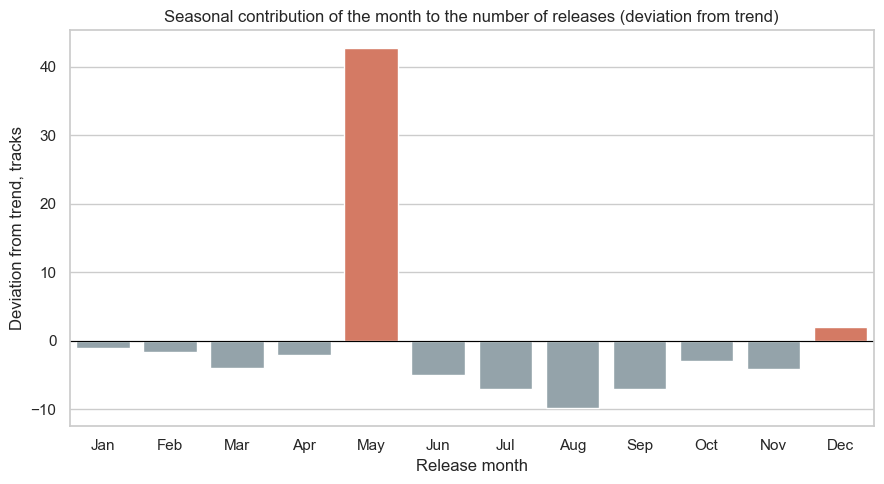

In [13]:
# average seasonal contribution by calendar month (deviation from the trend, in tracks)
seasonal_by_month = decomp.seasonal.groupby(decomp.seasonal.index.month).mean()
seasonal_by_month.index = month_names  # month_names defined in section 5

fig, ax = plt.subplots()
colors = ["#e76f51" if v > 0 else "#90a4ae" for v in seasonal_by_month.values]
sns.barplot(x=seasonal_by_month.index, y=seasonal_by_month.values,
            hue=seasonal_by_month.index, palette=colors, legend=False, ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Seasonal contribution of the month to the number of releases (deviation from trend)")
ax.set_xlabel("Release month")
ax.set_ylabel("Deviation from trend, tracks")
plt.tight_layout()
plt.show()

**Conclusion for the time series.** The decomposition separates three effects:

- **Trend** rises steadily - but, as noted above, this is largely the survivorship bias of the top-2023 sample rather than pure market growth, so we read it cautiously.
- **Seasonality** reproduces and refines the conclusion of Hypothesis 3: **May** stands out most strongly upward, with December also positive; summer months and early spring are negative. That is, labels concentrate releases in May year after year.
- **Residual** is small and without clear structure: this means the trend and seasonality describe the series well, and large one-off spikes (the abnormally large May 2022) go into the residual.

Practical takeaway: the peak of release activity is May. But, as H3 showed, this is a peak in the *number* of releases, not in median streams, so releasing "in season" does not by itself guarantee popularity.

## 8. Final conclusions

| Hypothesis | Result | In short |
|---|---|---|
| H1: major streamed more than minor | not supported | the difference in streams between major and minor is not statistically significant (p > 0.1) |
| H2: playlists matter more than sound | supported | correlation of streams with the number of playlists (~0.83) is an order of magnitude higher than with any audio feature |
| H3: release seasonality | partially supported | seasonality exists in the *number* of releases (peak in May, confirmed by decomposition), but not in *streams*: the month's stream peak does not coincide with the release peak |
| H4: more co-authors -> charts | not supported | the link between artist_count and charting is practically zero (rho ~ 0.02) |

**Main takeaway.** What makes a track a hit in this data is, first and foremost, getting into
playlists (distribution), not the musical characteristics (key, tempo, danceability) or formal
attributes like the number of co-authors and the release month.

*Exact p-values and correlation coefficients are in the outputs of the corresponding cells above.*